# Домашнее задание 3. Линейная интерполяция

## Введение

На практике физические свойства газа (вязкость, коэффициент сверхсжимаемости, объёмный коэффициент и др.) известны лишь в дискретных точках — из лабораторных измерений или табличных расчётов. Чтобы получить значение свойства при произвольном давлении, необходима **интерполяция**.

**Линейная интерполяция** — простейший и наиболее распространённый метод: между двумя соседними известными точками $(x_i,\, y_i)$ и $(x_{i+1},\, y_{i+1})$ значение приближается прямой линией:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

где $x_p$ — точка, в которой нужно найти значение, а $y_p$ — результат интерполяции.

## Задание

### Что нужно сделать

1. **Считать файл `interp_data.csv`** и загрузить данные давления и вязкости.

2. **Дополнить таблицу столбцами Z и Bg** — используя класс `Fluid` из ДЗ-2, рассчитать коэффициент сверхсжимаемости и объёмный коэффициент расширения для каждого давления при фиксированной температуре $T = 310$ К.

3. **Реализовать класс `LinearInterpolator`** — собственный линейный интерполятор **без использования** встроенных функций интерполяции (numpy, scipy, pandas и т.д.).
   - Класс инициализируется массивами `x` и `y`.
   - Метод `predict(xp)` возвращает интерполированное значение $y_p$ для заданного $x_p$.

4. **Сравнить свой интерполятор с `numpy.interp`** — построить графики, на которых видно совпадение (или расхождение) результатов.

---

## Часть 1. Загрузка и обогащение данных

Считайте файл `interp_data.csv`. Затем вставьте свой класс `Fluid` из ДЗ-2 (с реализованными методами `get_Z` и `get_Bg`) и создайте объект `Fluid` со своими параметрами из `hw2_data.csv`.

Для каждого давления из таблицы рассчитайте Z и Bg при $T = 310$ К и добавьте результаты как новые столбцы.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# === Вставьте сюда свой класс Fluid из ДЗ-2 (с реализованными get_Z и get_Bg) ===

class Fluid:
    """Класс для расчёта свойств природного газа по методике GERG-91 мод."""
    
    Pstd = 1       # стандартное давление, атм
    Tstd = 293.15  # стандартная температура, К
    
    def __init__(self, rho_c: float, xa: float, xy: float):
        self.rho_c = rho_c
        self.xa = xa
        self.xy = xy
    
    def get_Z(self, P: float, T: float) -> float:
        """
        Рассчитать коэффициент сверхсжимаемости Z по методике GERG-91 мод.

        Параметры
        ----------
        P : float
            Давление, атм.
        T : float
            Температура, К.

        Возвращает
        ----------
        float
            Коэффициент сверхсжимаемости Z.
        """
        M_CH4 = 0.016  # кг/кмоль
        M_N2 =  0.028   # кг/кмоль
        M_CO2 = 0.044   # кг/кмоль
        R = 0.008314  # МПа·м³/(кмоль·К)
        
        P_mpa = P * 0.101325 # в МПа
        xe = 1 - self.xa - self.xy # (молярная доля эквивалентного углеводорода)
        M = xe * M_CH4 + self.xa * M_N2 + self.xy * M_CO2 # молярная масса смеси
        #  сжимаемость при стандартных условиях
        z_c = 1 - (0.0741 * self.rho_c - 0.006 - 0.063 * self.xa - 0.0575 * self.xy) ** 2
        # Молярная масса эквивалентного углеводорода
        M3 = (24.05525 * z_c * self.rho_c - 28.0135 * self.xa - 44.01 * self.xy) / xe
        H = 128.64 + 47.479 * M3 # расчет H (34)
        
        B1 = (-0.425468 + 2.865e-3 * T - 4.62073e-6 * T ** 2 + (8.77118e-4 - 5.56281e-6 * T + 8.81514e-9 * T ** 2) * H \
              + (-8.24747e-7 + 4.31436e-9 * T - 6.08319e-12 * T ** 2) * H ** 2) # (23)
        B2 = -0.1446 + 7.4091e-4 * T - 9.1195e-7 * T ** 2 # (24)
        B23 = -0.339693 + 1.61176e-3 * T - 2.04429e-6 * T ** 2 # (25)
        B3 = -0.86834 + 4.0376e-3 * T - 5.1657e-6 * T ** 2 # (26)
        B_ = 0.72 + 1.875e-5 * (320 - T) ** 2 # (32)
        C1 = (-0.302488 + 1.95861e-3 * T - 3.16302e-6 * T ** 2 + (6.46422e-4 - 4.22876e-6 * T + 6.88157e-9 * T ** 2) * H \
              + (-3.32805e-7 + 2.2316e-9 * T - 3.67713e-12 * T ** 2) * H ** 2) # (27)
        C2 = 7.8498e-3 - 3.9895e-5 * T + 6.1187e-8 * T ** 2 # (28)
        C3 = 2.0513e-3 + 3.4888e-5 * T - 8.3703e-8 * T ** 2 # (29)
        C223 = 5.52066e-3 - 1.68609e-5 * T + 1.57169e-8 * T ** 2 # (30)
        C233 = 3.58783e-3 + 8.06674e-6 * T - 3.25798e-8 * T ** 2 # (31)
        
        B_ = 0.72 + 1.875e-5 * (320 - T) ** 2 # (32)
        C_ = 0.92 + 0.0013 * (T - 270) # (33)
        
        # Коэффициенты уравнения состояния
        Bm = (xe ** 2 * B1 + xe * self.xa * B_ * (B1 + B2) - 1.73 * xe * self.xy * math.sqrt(B1 * B3) + self.xa ** 2 \
               * B2 + 2 * self.xa * self.xy * B23 + self.xy ** 2 * B3)
        Cm = (xe ** 3 * C1 + 3 * xe ** 2 * self.xa * C_ * (C1 ** 2 * C2) ** (1/3) + 2.76 * xe ** 2 * self.xy * (C1 ** 2 * C3) ** (1/3) \
               + 3 * xe * self.xa ** 2 * C_ * (C1 * C2 ** 2) ** (1/3) + 6.6 * xe * self.xa * self.xy * (C1 * C2 * C3) ** (1/3) \
               + 2.76 * xe * self.xy ** 2 * (C1 * C3 ** 2) ** (1/3) + self.xa ** 3 * C2 + 3 * self.xa ** 2 * self.xy * C223 \
               + 3 * self.xa * self.xy ** 2 * C233 + self.xy ** 3 * C3)
        
        r_M = (P_mpa * 1000) / (R * T) # молярная плотность

        # Рассчет z (19)
        b = 1e3 * P_mpa / (2.7715 * T)
        z = 1 + Bm * r_M + Cm * (r_M ** 2)

        # Фактор сжимаемости при стандартных условиях Z
        B0 = b * Bm
        C0 = b ** 2 * Cm
        A1 = 1 + B0
        A0 = 1 + 1.5 * (B0 + C0)
        A2 =  (A0 - (A0 ** 2 - A1 ** 3) ** (1/2)) ** (1/3)
        Z = (1 + A2 + A1 / A2) / 3
        return Z
        
    def get_Bg(self, P: float, T: float) -> float:
        """
        Рассчитать объёмный коэффициент расширения газа Bg.

        Bg = (Pstd * Z * T) / (P * Tstd)

        Параметры
        ----------
        P : float
            Давление, атм.
        T : float
            Температура, К.

        Возвращает
        ----------
        float
            Объёмный коэффициент расширения Bg.
        """
        Z = self.get_Z(P, T)
        Bg = (self.Pstd * Z * T) / (P * self.Tstd)
        return Bg

# === Загрузка данных ===

df = pd.read_csv('interp_data.csv', sep=';')
display(df.head())

# === Создание объекта Fluid (подставьте свои параметры из hw2_data.csv) ===

df2 = pd.read_csv('hw2_data.csv', sep=';', index_col=0)
display(df2)

# Мои данные (индекс 15)
my_data = df2.loc[2]

rho_c = my_data['rho_c, kg/m3'] # TODO: ваше значение плотности
xa_percent = my_data['xa, mol. %']
xy_percent = my_data['xy, mol. %']

# Перевод процентов в доли 
xa = xa_percent / 100 # TODO: ваша мольная доля азота
xy = xy_percent / 100 # TODO: ваша мольная доля CO₂

# Вывод для проверки
print(f"\nМои данные (Андреев Вячеслав Олегович, индекс 2):")
print(f"rho_c = {rho_c} кг/м³")
print(f"xa = {xa_percent}%")
print(f"xy = {xy_percent}%")
print(f"Доля метана = {1 - xa - xy:.6f}\n")

fluid = Fluid(rho_c=rho_c, xa=xa, xy=xy)

# === Расчёт Z и Bg для каждого давления при T = 310 К ===

T = 310  # К
df['Z'] = df['pressure, atm'].apply(lambda p: fluid.get_Z(p, T))
df['Bg'] = df['pressure, atm'].apply(lambda p: fluid.get_Bg(p, T))

display(df.head())
print(f"\nРассчитано {len(df)} значений")
print(f"Диапазон Z: [{df['Z'].min():.4f}, {df['Z'].max():.4f}]")
print(f"Диапазон Bg: [{df['Bg'].min():.4f}, {df['Bg'].max():.4f}]")


,"pressure, atm","viscosity, cP"
0,1.000000,0.018312
1,3.010101,0.018321
2,5.020202,0.018330
3,7.030303,0.018339
4,9.040404,0.018349


,student,"xa, mol. %","xy, mol. %","rho_c, kg/m3"
0,Али Иван,0.3745,0.9507,0.6799
1,Альзейн Мохаммад Альжавад,0.7320,0.5987,0.6799
2,Андреев Вячеслав Олегович,0.1560,0.1560,0.6799
3,Гедымин Герман Константинович,0.0581,0.8662,0.6799
4,Инюхин Дмитрий Романович,0.6011,0.7081,0.6799
5,Котиев Муслим Магометович,0.0206,0.9699,0.6799
6,Пугачев Александр Сергеевич,0.8324,0.2123,0.6799
7,Пулидо Де Ла Крус Лианнес,0.1818,0.1834,0.6799
8,Самохвалов Денис Александрович,0.3042,0.5248,0.6799
9,Федореев Юрий Георгиевич,0.4319,0.2912,0.6799



Мои данные (Андреев Вячеслав Олегович, индекс 2):
rho_c = 0.6799 кг/м³
xa = 0.156%
xy = 0.156%
Доля метана = 0.996880



,"pressure, atm","viscosity, cP",Z,Bg
0,1.000000,0.018312,0.998434,1.055823
1,3.010101,0.018321,0.995294,0.349657
2,5.020202,0.018330,0.992165,0.208994
3,7.030303,0.018339,0.989047,0.148770
4,9.040404,0.018349,0.985942,0.115328



Рассчитано 100 значений
Диапазон Z: [0.8353, 0.9984]
Диапазон Bg: [0.0044, 1.0558]


---

## Часть 2. Собственный интерполятор

Реализуйте класс `LinearInterpolator`.

### Требования

- `__init__(self, x, y)` — принимает два списка (или массива) одинаковой длины. Значения `x` должны быть отсортированы по возрастанию.
- `predict(self, xp)` — принимает скалярное значение `xp` и возвращает интерполированное значение `yp`.
- **Запрещено** использовать `numpy`, `scipy`, `pandas` и любые другие библиотечные функции интерполяции внутри класса. Только чистый Python (`list`, `for`, `if`, арифметика).

### Подсказка

Алгоритм для `predict(xp)`:
1. Найти индекс $i$ такой, что $x_i \le x_p < x_{i+1}$.
2. Применить формулу линейной интерполяции:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

> Что делать, если `xp` совпадает с последней точкой $x_n$? Обработайте этот граничный случай через экстраполяцию по двум граничным точкам

In [64]:
class LinearInterpolator:
    """
    Линейный интерполятор.
    
    Параметры
    ----------
    x : list
        Узловые точки (отсортированы по возрастанию).
    y : list
        Значения функции в узловых точках.
    """
    
    def __init__(self, x, y):
        # TODO: сохранить x и y, проверить что длины совпадают
        if len(x) != len(y):
            raise ValueError(f"Длины x и y должны совпадать")
        '''
        По условию узловые точки отсортированы по возрастанию, поэтому в коде будет лишь проверка на соблюдение условия, а не сама сортировка
        '''
        for i in range(len(x) - 1):
            if x[i] >= x[i + 1]:
                raise ValueError(f"x должны быть отсортированы по возрастанию")
        self.x = x
        self.y = y
    
    def predict(self, xp):
        """
        Вычислить интерполированное значение yp для заданного xp.
        
        Параметры
        ----------
        xp : float
            Точка, в которой нужно найти значение.
        
        Возвращает
        ----------
        float
            Интерполированное значение yp.
        """
        n = len(self.x)
        # Граничный случай, когда xp совпадает с последней точкой - берем последние две точки
        if xp >= self.x[-1]:
            i = n - 2 # берем предпоследний, а i + 1 даст последний индексы
        else:
            '''
            интервал по условию
            '''
            i = 0
            for idx in range(n - 1):
                if self.x[idx] <= xp < self.x[idx + 1]:
                    i = idx
                    break
                    
        x0, x1 = self.x[i], self.x[i + 1]
        y0, y1 = self.y[i], self.y[i + 1]
        yp = y0 + (y1 - y0) / (x1 - x0) * (xp - x0)
        return yp

---

## Часть 3. Сравнение с `numpy.interp`

Сгенерируйте набор промежуточных точек давления (например, 500 точек в диапазоне от 1 до 200 атм). Вычислите интерполированные значения **вязкости**, **Z** и **Bg** двумя способами:

1. Ваш `LinearInterpolator`
2. Функция `numpy.interp`

Постройте графики, на которых отображены:
- Исходные табличные точки (маркерами)
- Кривая вашего интерполятора
- Кривая `numpy.interp`

In [32]:
pres = np.linspace(1, 200, 500)

x = df['pressure, atm'].values
y_Z = df['Z'].values
y_Bg = df['Bg'].values

# === Способ 1: собственный интерполятор ===
interp_Z = LinearInterpolator(x.tolist(), y_Z.tolist())
interp_Bg = LinearInterpolator(x.tolist(), y_Bg.tolist())

# Предсказываем для всех точек (используем list comprehension, т.к. predict работает со скаляром)
Z_custom = np.array([interp_Z.predict(p) for p in pres])
Bg_custom = np.array([interp_Bg.predict(p) for p in pres])

# === Способ 2: numpy.interp ===
Z_numpy = np.interp(pres, x, y_Z)
Bg_numpy = np.interp(pres, x, y_Bg)

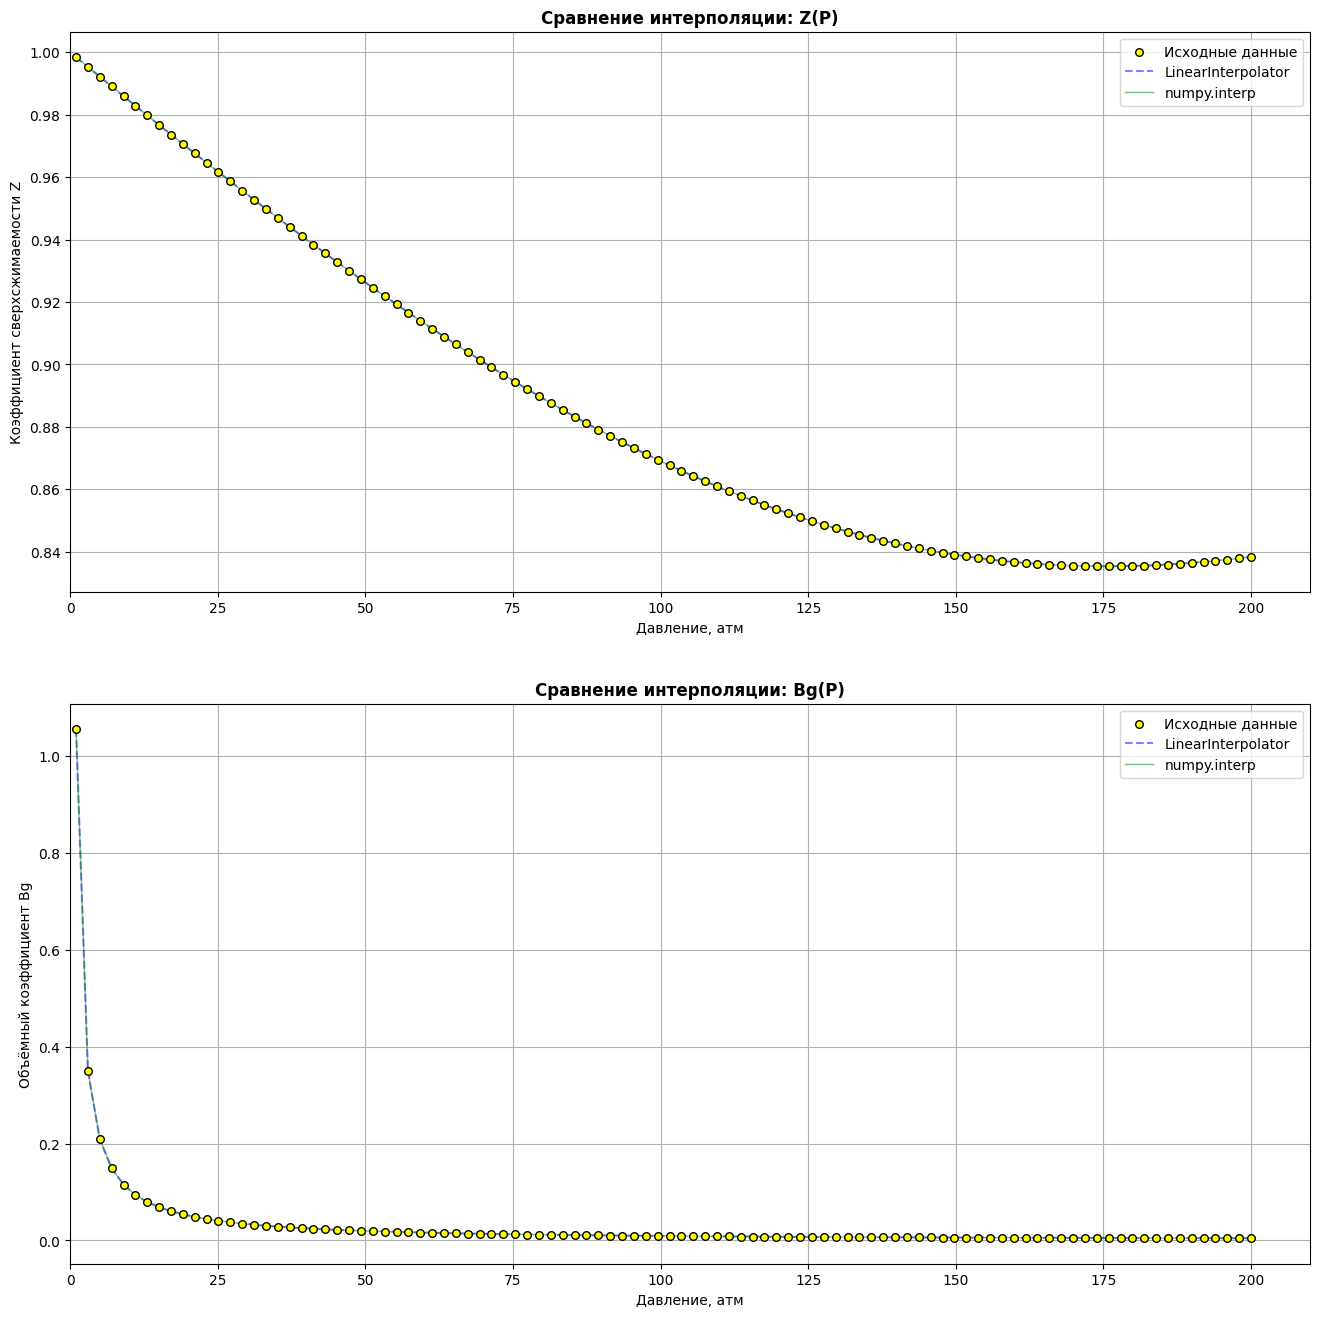

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(16, 16))

# === График 1: Коэффициент сверхсжимаемости Z ===
ax1 = axes[0]

ax1.scatter(x, y_Z, c='yellow', s=30, label='Исходные данные', zorder=5, edgecolors='black') # исходные точки
ax1.plot(pres, Z_custom, 'b--', linewidth=1.5, label='LinearInterpolator', alpha=0.5) # custom интерполятор
ax1.plot(pres, Z_numpy, 'g-', linewidth=1, label='numpy.interp', alpha=0.5) # numpy.interp

ax1.set_xlabel('Давление, атм')
ax1.set_ylabel('Коэффициент сверхсжимаемости Z')
ax1.set_title('Сравнение интерполяции: Z(P)', fontweight='bold')
ax1.grid()
ax1.legend()
ax1.set_xlim([0, 210])

# === График 2: Объёмный коэффициент Bg ===
ax2 = axes[1]

ax2.scatter(x, y_Bg, c='yellow', s=30, label='Исходные данные', zorder=5, edgecolors='black') # исходные точки
ax2.plot(pres, Bg_custom, 'b--', linewidth=1.5, label='LinearInterpolator', alpha=0.5)  # custom интерполятор
ax2.plot(pres, Bg_numpy, 'g-', linewidth=1, label='numpy.interp', alpha=0.5) # numpy.interp

ax2.set_xlabel('Давление, атм')
ax2.set_ylabel('Объёмный коэффициент Bg')
ax2.set_title('Сравнение интерполяции: Bg(P)', fontweight='bold')
ax2.grid()
ax2.legend()
ax2.set_xlim([0, 210])

plt.show()